In [21]:
import pandas as pd
import numpy as np

PART A:

In [31]:
df = pd.read_csv("mystery_data(in).csv")
df.head()

,101,40,M,5.6,45
0,102,90,M,10.3,97
1,103,84,F,7.7,98
2,104,52,M,11.6,98
3,105,43,F,8.4,47
4,106,40,M,8.8,60


In [32]:
df_renamed = df.rename(columns={
    '101': 'ID',
    '40': 'Maths',
    'M': 'Gender',
    '5.6': 'StudyHours',  # corrected the typo here
    '45': 'Science'
})
print(df_renamed)


     ID  Maths Gender  StudyHours  Science
0   102     90      M        10.3       97
1   103     84      F         7.7       98
2   104     52      M        11.6       98
3   105     43      F         8.4       47
4   106     40      M         8.8       60
..  ...    ...    ...         ...      ...
94  196     42      M        10.2       61
95  197     66      M        10.9       65
96  198     68      F        10.6       58
97  199     71      M         7.9       53
98  200     89      M        10.1       90

[99 rows x 5 columns]


PART B:

In [35]:
# remove any rows where study hourse is missing or invalid, assuming you have already named the columns?
df_renamed['StudyHours'] = pd.to_numeric(df_renamed['StudyHours'], errors='coerce')
df_cleaned = df_renamed.dropna(subset=['StudyHours'])
print(df_cleaned)

     ID  Maths Gender  StudyHours  Science
0   102     90      M        10.3       97
1   103     84      F         7.7       98
2   104     52      M        11.6       98
3   105     43      F         8.4       47
4   106     40      M         8.8       60
..  ...    ...    ...         ...      ...
94  196     42      M        10.2       61
95  197     66      M        10.9       65
96  198     68      F        10.6       58
97  199     71      M         7.9       53
98  200     89      M        10.1       90

[98 rows x 5 columns]


In [36]:
# Create New Column that Calculates total Score
df_renamed['TotalScore'] = df_renamed['Maths'] + df_renamed['Science']
print(df_renamed)

     ID  Maths Gender  StudyHours  Science  TotalScore
0   102     90      M        10.3       97         187
1   103     84      F         7.7       98         182
2   104     52      M        11.6       98         150
3   105     43      F         8.4       47          90
4   106     40      M         8.8       60         100
..  ...    ...    ...         ...      ...         ...
94  196     42      M        10.2       61         103
95  197     66      M        10.9       65         131
96  198     68      F        10.6       58         126
97  199     71      M         7.9       53         124
98  200     89      M        10.1       90         179

[99 rows x 6 columns]


In [38]:
# print the Top 5 Students on total Score
top_students = df_renamed.nlargest(5, 'TotalScore')
print(top_students)

     ID  Maths Gender  StudyHours  Science  TotalScore
16  118     93      M         9.1       97         190
0   102     90      M        10.3       97         187
1   103     84      F         7.7       98         182
56  158     81      M         3.3       98         179
76  178     87      F         4.8       92         179


PART C

In [46]:
# the university claims that, on average, the students score 70 marks in maths. Check wheather students who study more that 10 hourse per week score significantly higher than
# this benchmark. make sure to conclude based on your hypothesis

import pandas as pd
from scipy.stats import ttest_1samp
# students who are having studyHourse value greater than 10
more_than_10hrs = df_renamed[df_renamed['StudyHours'] > 10]

# Perform a one-sample t-test against the population mean = 70
t_stat, p_value = ttest_1samp(more_than_10hrs['Maths'], popmean=70)

# One-tailed test: we want to check if mean is significantly **greater** than 70
p_value_one_tailed = p_value / 2

# Print results
print("T-statistic:", t_stat)
print("One-tailed P-value:", p_value_one_tailed)

# Conclusion
alpha = 0.05
if p_value_one_tailed < alpha and t_stat > 0:
    print("Conclusion: Students who study more than 10 hours/week score significantly higher than 70.")
else:
    print("Conclusion: No significant evidence that students who study more than 10 hours/week score higher than 70.")


T-statistic: -1.0992432648833956
One-tailed P-value: 0.13903747723288548
Conclusion: No significant evidence that students who study more than 10 hours/week score higher than 70.


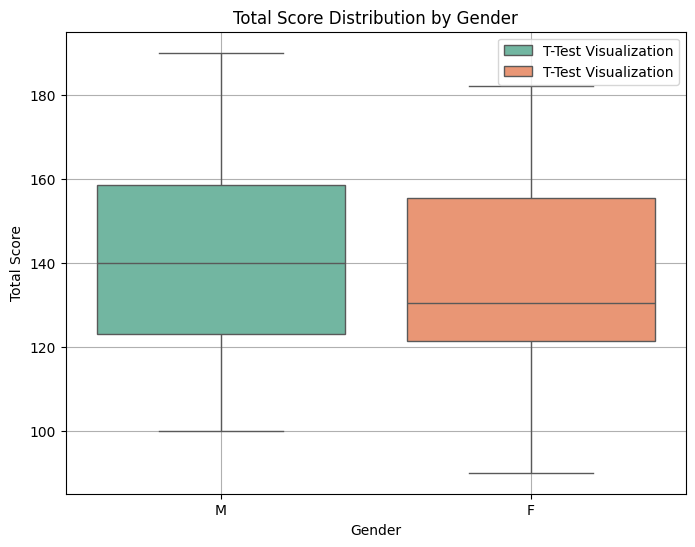

In [57]:
# visualize the difference in total score between genders using any suitable chart. Write two line insights
import matplotlib.pyplot as plt
import seaborn as sns
# Plot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Gender', y='TotalScore', data=df_renamed, palette='Set2', label = 'T-Test Visualization')
plt.title('Total Score Distribution by Gender')
plt.xlabel('Gender')
plt.ylabel('Total Score')
plt.grid(True)
plt.legend()
plt.show()
